In [12]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Le but de ce projet est de s'intéresser au cancer du sein qui touche les femmes et 1% d'hommes dans le monde.
Dans un premier temps, on va s'intéresser aux différentes features des personnes concernés dans notre jeu de données

In [13]:
file = pd.read_excel('brca_metabric_clinical_data.xlsx')
brca = file.dropna(subset = "Patient's Vital Status")
brca

,Study ID,Patient ID,Sample ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,...,Relapse Free Status (Months),Relapse Free Status,Number of Samples Per Patient,Sample Type,Sex,3-Gene classifier subtype,TMB (nonsynonymous),Tumor Size,Tumor Stage,Patient's Vital Status
0,brca_metabric,MB-0000,MB-0000,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,NO,claudin-low,...,140.500000,0:Not Recurred,1,Primary,Female,ER-/HER2-,0.000000,22.0,2.0,Living
1,brca_metabric,MB-0002,MB-0002,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,NO,LumA,...,84.633333,0:Not Recurred,1,Primary,Female,ER+/HER2- High Prolif,2.615035,10.0,1.0,Living
2,brca_metabric,MB-0005,MB-0005,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,YES,LumB,...,153.300000,1:Recurred,1,Primary,Female,NaN,2.615035,15.0,2.0,Died of Disease
3,brca_metabric,MB-0006,MB-0006,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,YES,LumB,...,164.933333,0:Not Recurred,1,Primary,Female,NaN,1.307518,25.0,2.0,Living
4,brca_metabric,MB-0008,MB-0008,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,YES,LumB,...,18.800000,1:Recurred,1,Primary,Female,ER+/HER2- High Prolif,2.615035,40.0,2.0,Died of Disease
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1980,brca_metabric,MB-7295,MB-7295,43.10,BREAST CONSERVING,Breast Cancer,Breast Invasive Lobular Carcinoma,High,NO,LumA,...,196.866667,0:Not Recurred,1,Primary,Female,ER+/HER2- Low Prolif,5.230071,25.0,NaN,Living
1981,brca_metabric,MB-7296,MB-7296,42.88,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,NO,LumB,...,16.300000,1:Recurred,1,Primary,Female,NaN,7.845106,20.0,NaN,Died of Disease
1982,brca_metabric,MB-7297,MB-7297,62.90,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,NO,LumB,...,122.800000,1:Recurred,1,Primary,Female,NaN,5.230071,25.0,NaN,Died of Disease
1983,brca_metabric,MB-7298,MB-7298,61.16,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,NO,LumB,...,86.233333,0:Not Recurred,1,Primary,Female,ER+/HER2- High Prolif,19.612766,25.0,NaN,Died of Other Causes


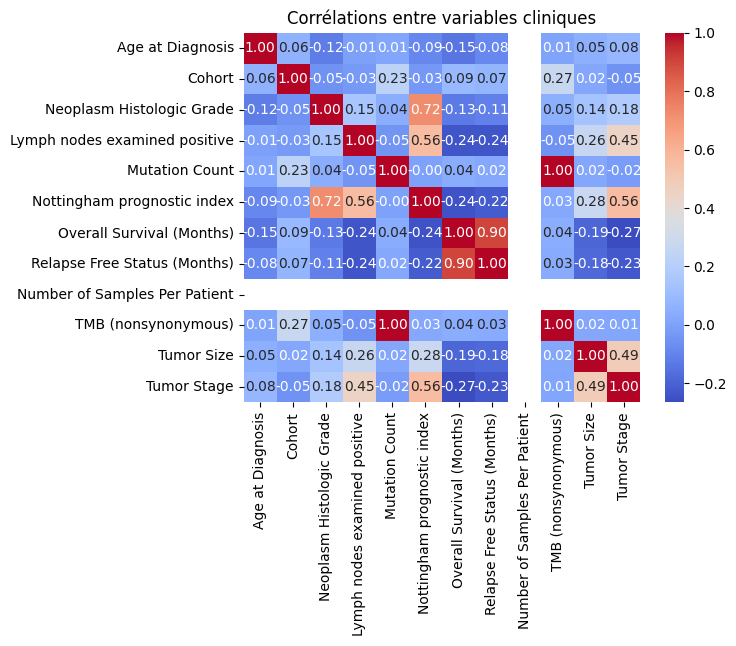

In [14]:
heatmap = brca.select_dtypes(include=["float64", "int64"]).corr()
sns.heatmap(heatmap, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corrélations entre variables cliniques")
plt.show()

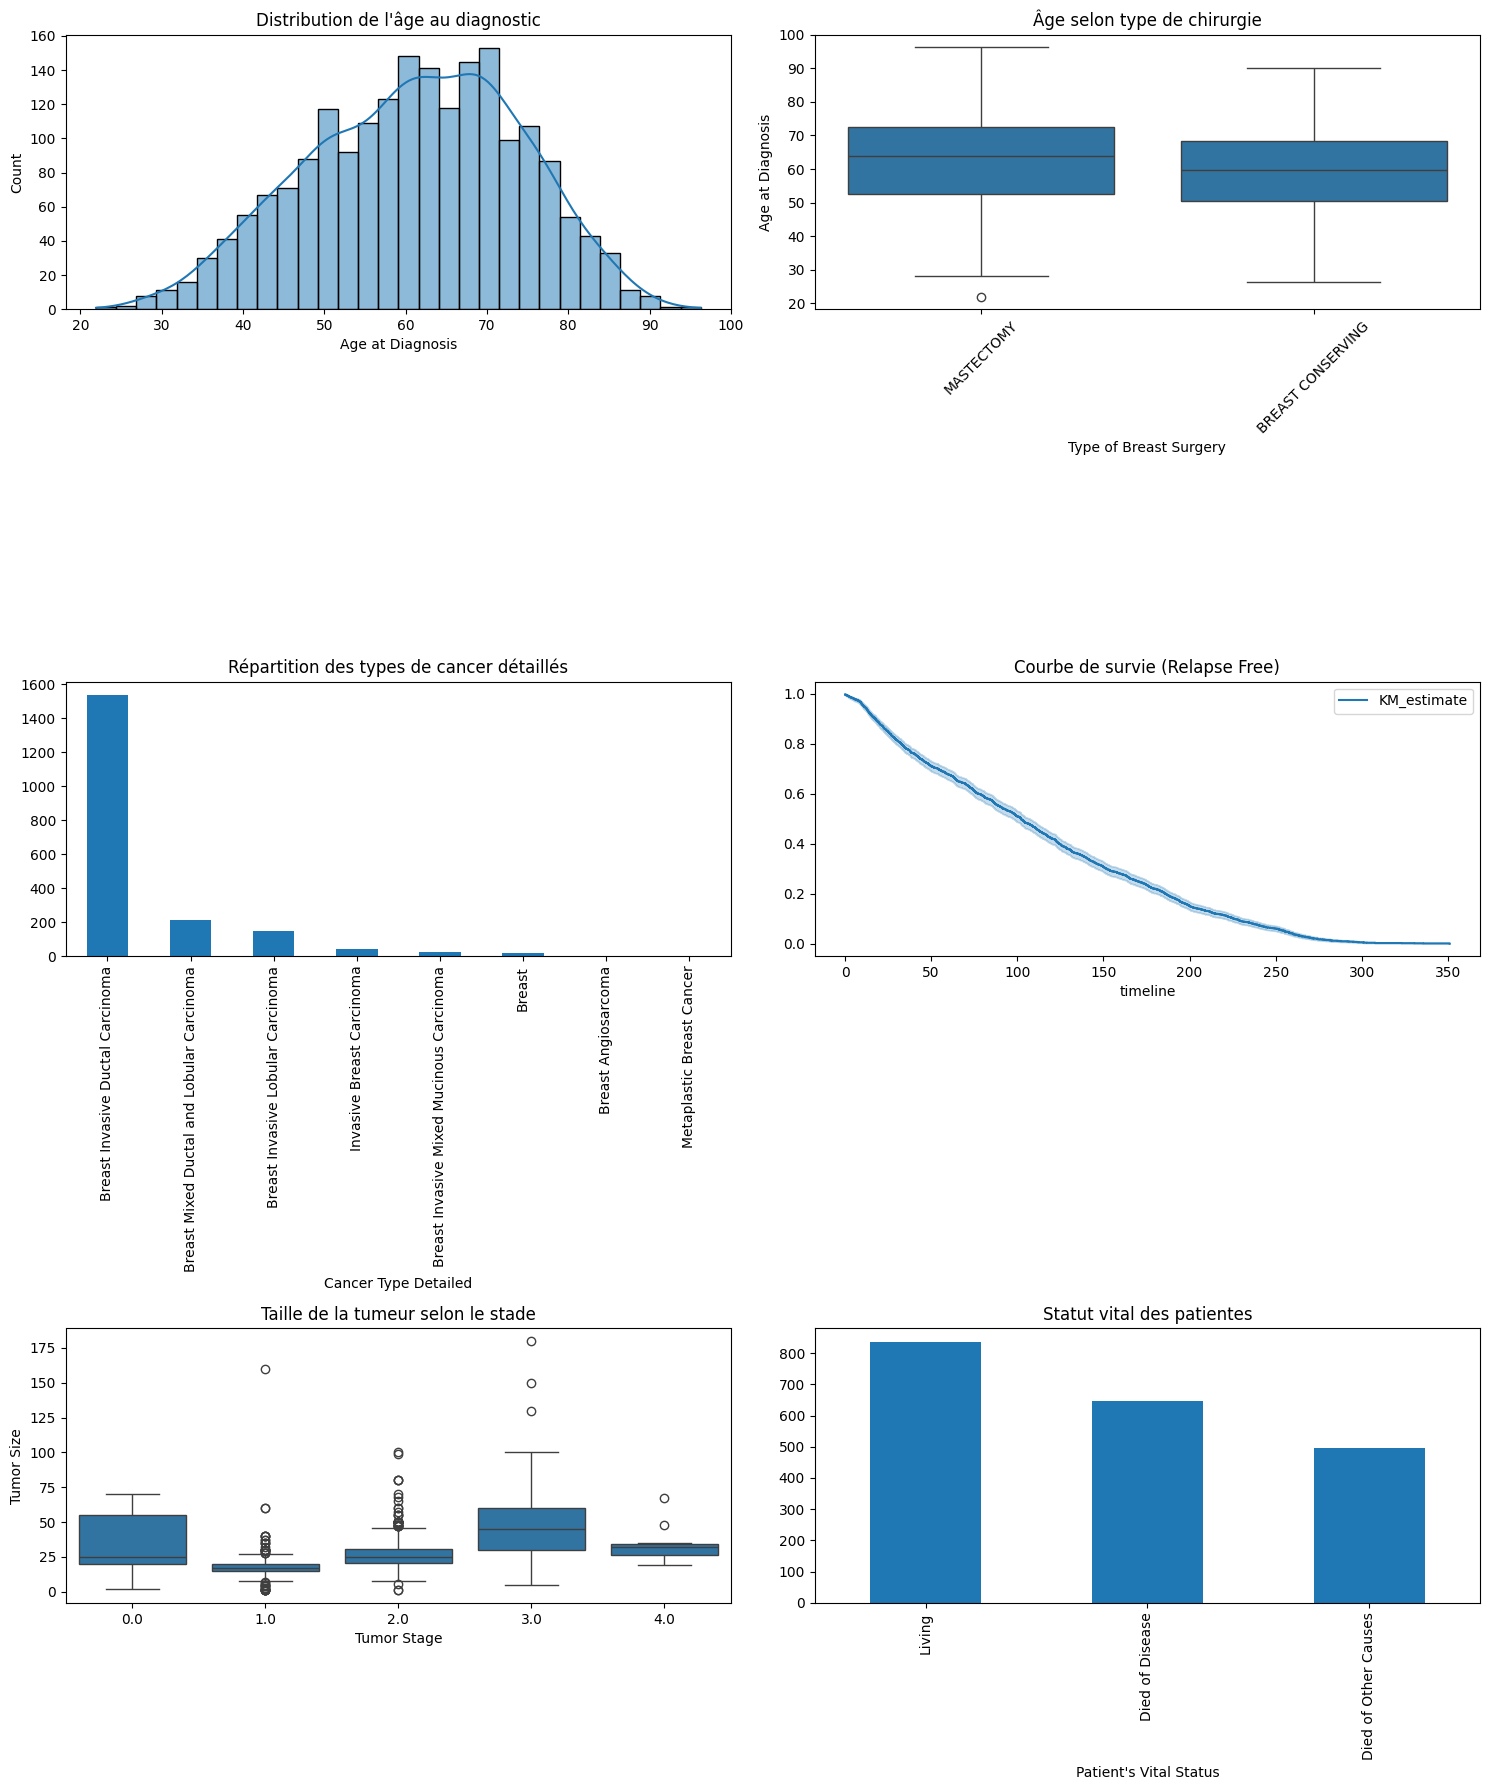

In [15]:
from lifelines import KaplanMeierFitter

# Préparer figure avec 3 lignes × 2 colonnes
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

# 1. Histogramme âge au diagnostic
sns.histplot(brca["Age at Diagnosis"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution de l'âge au diagnostic")

# 2. Boxplot âge vs chirurgie
sns.boxplot(x="Type of Breast Surgery", y="Age at Diagnosis", data=brca, ax=axes[1])
axes[1].set_title("Âge selon type de chirurgie")
axes[1].tick_params(axis='x', rotation=45)

# 3. Bar chart types de cancer détaillés
brca["Cancer Type Detailed"].value_counts().plot(kind="bar", ax=axes[2])
axes[2].set_title("Répartition des types de cancer détaillés")

# 4. Courbe de survie Kaplan-Meier
kmf = KaplanMeierFitter()
T = brca["Relapse Free Status (Months)"]
E = brca["Relapse Free Status"].apply(lambda x: 1 if "Recurred" in str(x) else 0)
kmf.fit(T, event_observed=E)
kmf.plot_survival_function(ax=axes[3])
axes[3].set_title("Courbe de survie (Relapse Free)")

# 5. Boxplot taille vs stade
sns.boxplot(x="Tumor Stage", y="Tumor Size", data=brca, ax=axes[4])
axes[4].set_title("Taille de la tumeur selon le stade")

# 6. Bar chart statut vital
brca["Patient's Vital Status"].value_counts().plot(kind="bar", ax=axes[5])
axes[5].set_title("Statut vital des patientes")

plt.tight_layout()
plt.savefig("breast_cancer_clinical_analysis.png")
plt.show()

I - On constate que l'âge moyen auquel on constate le plus de cancer du sein se situe entre 40 - 60 ans 

II - On observe une tendance à la conservation du sein chez les femmes les plus jeunes

III - Le type le plus fréquent est le carcinome canalaire invasif. Les autres types sont beaucoup moins représentés.

IV - La probabilité de rester sans rechute diminue progressivement avec le temps. De plus, la pente est douce et donc le risque de rechute est faible mais cela varie un peu plus après 100 mois.

V - On peut voir que la taille de la tumeur varie en fonction de son stage 

In [16]:
brca = brca.rename(columns={
    "Study ID": "study_id",
    "Patient ID": "patient_id",
    "Sample ID": "sample_id",
    "Age at Diagnosis": "age_diagnosis",
    "Type of Breast Surgery": "breast_surgery",
    "Cancer Type": "cancer_type",
    "Cancer Type Detailed": "cancer_type_detailed",
    "Cellularity": "cellularity",
    "Chemotherapy": "chemotherapy",
    "Pam50 + Claudin-low subtype": "pam50_subtype",
    "Cohort": "cohort",
    "ER status measured by IHC": "er_status_ihc",
    "ER Status": "er_status",
    "Neoplasm Histologic Grade": "histologic_grade",
    "HER2 status measured by SNP6": "her2_status_snp6",
    "HER2 Status": "her2_status",
    "Tumor Other Histologic Subtype": "tumor_other_subtype",
    "Hormone Therapy": "hormone_therapy",
    "Inferred Menopausal State": "menopause_state",
    "Integrative Cluster": "integrative_cluster",
    "Primary Tumor Laterality": "tumor_laterality",
    "Lymph nodes examined positive": "lymph_nodes_positive",
    "Mutation Count": "mutation_count",
    "Nottingham prognostic index": "nottingham_index",
    "Oncotree Code": "oncotree_code",
    "Overall Survival (Months)": "os_months",
    "Overall Survival Status": "os_status",
    "PR Status": "pr_status",
    "Radio Therapy": "radiotherapy",
    "Relapse Free Status (Months)": "rfs_months",
    "Relapse Free Status": "rfs_status",
    "Number of Samples Per Patient": "samples_per_patient",
    "Sample Type": "sample_type",
    "Sex": "sex",
    "3-Gene classifier subtype": "subtype_3gene",
    "TMB (nonsynonymous)": "tmb",
    "Tumor Size": "tumor_size",
    "Tumor Stage": "tumor_stage",
    "Patient's Vital Status": "vital_status"
})


In [17]:
# Nettoyage du statut seul les patientes décédées du cancer nous intéresse sinon on les considère comme vivante
brca["vital_status"] = brca["vital_status"].replace({
    "Die by other causes": "Alive",
    "Died of Disease": "Dead",
    "Alive ": "Alive"
})

# Chimiothérapie
brca["chemotherapy"] = brca["chemotherapy"].replace({
    "YES": "Yes",
    "NO": "No"
})

# Mastectomie
brca["breast_surgery"] = brca["breast_surgery"].replace({
    "MASTECTOMY": "Mastectomy",
    "BREAST CONSERVING": "Breast Conserving"
})

#
brca["er_status"] = brca["er_status"].replace({"Positive": "Pos", "Negative": "Neg"})
brca["pr_status"] = brca["pr_status"].replace({"Positive": "Pos", "Negative": "Neg"})
brca["her2_status"] = brca["her2_status"].replace({"Positive": "Pos", "Negative": "Neg"})

# Signe de ménopause
brca["menopause_state"] = brca["menopause_state"].replace({
    "Pre": "Pre-menopause",
    "Post": "Post-menopause"
})


In [18]:
brca["vital_status"] = brca["vital_status"].replace({
    "Living": "Alive",
    "Died of Other Causes": "Alive",
    "Dead": "Dead"
})

brca["vital_event"] = brca["vital_status"].replace({
    "Alive": 0,
    "Dead": 1
})

/tmp/ipykernel_80594/2732551204.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  brca["vital_event"] = brca["vital_status"].replace({


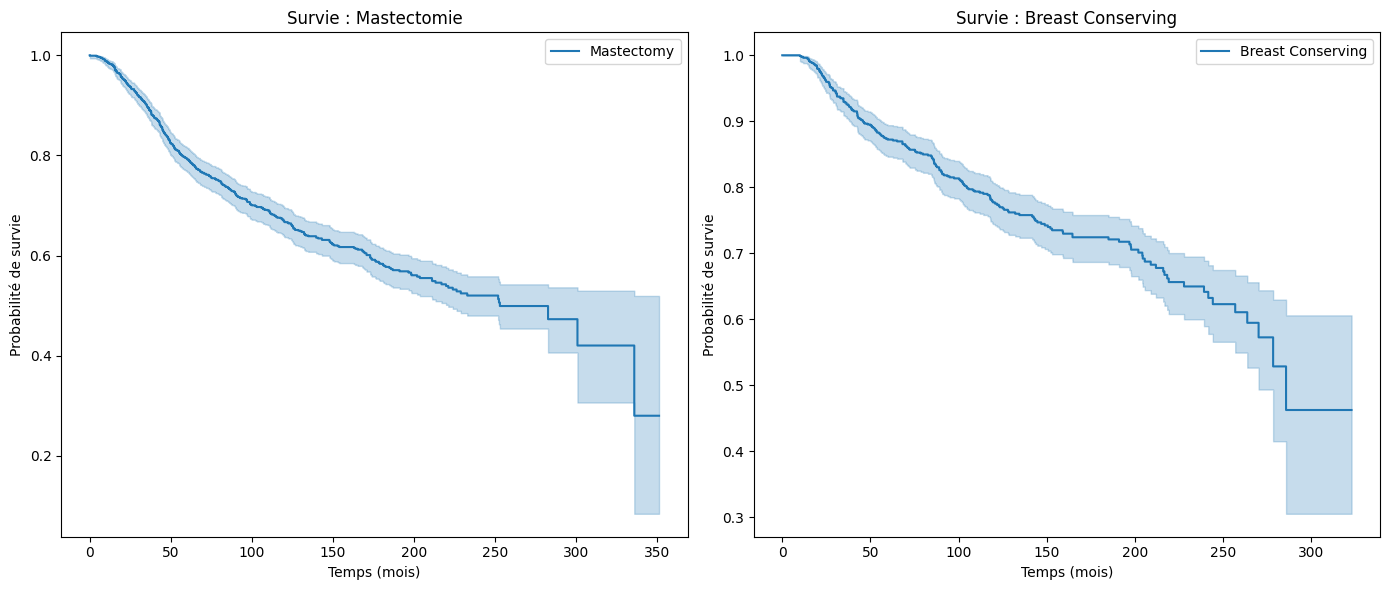

=== Résultats du test log-rank ===
   test_statistic             p   -log2(p)
0       27.736057  1.390467e-07  22.777927


In [19]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

# Séparation des groupes
group1 = brca[brca["breast_surgery"] == "Mastectomy"]
group2 = brca[brca["breast_surgery"] == "Breast Conserving"]

T1, E1 = group1["os_months"], group1["vital_event"]
T2, E2 = group2["os_months"], group2["vital_event"]

kmf1 = KaplanMeierFitter()
kmf2 = KaplanMeierFitter()

# --- SUBPLOTS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Courbe 1
kmf1.fit(T1, event_observed=E1, label="Mastectomy")
kmf1.plot_survival_function(ax=axes[0])
axes[0].set_title("Survie : Mastectomie")
axes[0].set_xlabel("Temps (mois)")
axes[0].set_ylabel("Probabilité de survie")

# Courbe 2
kmf2.fit(T2, event_observed=E2, label="Breast Conserving")
kmf2.plot_survival_function(ax=axes[1])
axes[1].set_title("Survie : Breast Conserving")
axes[1].set_xlabel("Temps (mois)")
axes[1].set_ylabel("Probabilité de survie")

plt.tight_layout()
plt.savefig("survival_breast_surgery.png")
plt.show()

# --- TEST LOG-RANK ---
results = logrank_test(T1, T2, event_observed_A=E1, event_observed_B=E2)

print("=== Résultats du test log-rank ===")
print(results.summary)


La p-value est extrêmement faible (< 0.0000002), bien en dessous du seuil classique de 0.05.

Cela indique une différence hautement significative entre les deux courbes de survie.

Les patientes ayant subi une mastectomie et celles ayant eu une chirurgie conservatrice ont des probabilités de survie statistiquement différentes.

In [20]:
# ============================
#  Nettoyage & Encodage METABRIC
# ============================

# --- Encodage simple 0/1 ---
brca["chemotherapy_bin"]      = brca["chemotherapy"].replace({"No": 0, "Yes": 1})
brca["hormone_therapy_bin"]   = brca["hormone_therapy"].replace({"No": 0, "Yes": 1})
brca["radiotherapy_bin"]      = brca["radiotherapy"].replace({"No": 0, "Yes": 1})

# --- Chirurgie : 0 = conservatrice, 1 = mastectomie ---
brca["mastectomy"] = brca["breast_surgery"].replace({
    "Breast Conserving": 0,
    "Mastectomy": 1
})

# --- Nettoyage tumor_stage ---
brca["tumor_stage"] = (
    brca["tumor_stage"]
    .astype(str).str.strip()
    .replace({
        "Stage 0": 0,
        "Stage I": 1,
        "Stage II": 2,
        "Stage III": 3,
        "Stage IV": 4,
        "Not Available": np.nan,
        "NA": np.nan,
        "NAN": np.nan,
        "NO": np.nan
    })
)
brca["tumor_stage"] = pd.to_numeric(brca["tumor_stage"], errors="coerce")

# --- Nettoyage hormone_therapy ---
brca["hormone_therapy"] = (
    brca["hormone_therapy"]
    .astype(str).str.strip().str.upper()
    .replace({
        "YES": 1,
        "NO": 0,
        "NONE": 0,
        "NOT AVAILABLE": np.nan,
        "NAN": np.nan
    })
)
brca["hormone_therapy_bin"] = brca["hormone_therapy"].astype(float)

# --- Nettoyage radiotherapy ---
brca["radiotherapy"] = (
    brca["radiotherapy"]
    .astype(str).str.strip().str.upper()
    .replace({
        "YES": 1,
        "NO": 0,
        "NONE": 0,
        "NOT AVAILABLE": np.nan,
        "NAN": np.nan
    })
)
brca["radiotherapy_bin"] = brca["radiotherapy"].astype(float)

# --- Statuts hormonaux (ER/PR/HER2) ---
brca["er_bin"]   = brca["er_status"].replace({"Pos": 1, "Neg": 0})
brca["pr_bin"]   = brca["pr_status"].replace({"Pos": 1, "Neg": 0})
brca["her2_bin"] = brca["her2_status"].replace({"Pos": 1, "Neg": 0})

# --- PAM50 (one-hot encoding) ---
brca = pd.get_dummies(brca, columns=["pam50_subtype"], drop_first=True)

# --- Variables continues ---
brca["tumor_size"]       = pd.to_numeric(brca["tumor_size"], errors="coerce")
brca["histologic_grade"] = pd.to_numeric(brca["histologic_grade"], errors="coerce")
brca["nottingham_index"] = pd.to_numeric(brca["nottingham_index"], errors="coerce")


/tmp/ipykernel_80594/3973429092.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  brca["chemotherapy_bin"]      = brca["chemotherapy"].replace({"No": 0, "Yes": 1})
/tmp/ipykernel_80594/3973429092.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  brca["mastectomy"] = brca["breast_surgery"].replace({
/tmp/ipykernel_80594/3973429092.py:38: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-i

In [21]:
from lifelines import CoxPHFitter

# Sélection des colonnes
cox_data = brca[[
    "os_months", "vital_event", "age_diagnosis",
    "chemotherapy_bin", "hormone_therapy_bin", "radiotherapy_bin",
    "mastectomy", "mutation_count"
]].dropna()

cph = CoxPHFitter()
cph.fit(cox_data, duration_col="os_months", event_col="vital_event")
print(cph.summary)


                         coef  exp(coef)  se(coef)  coef lower 95%  \
covariate                                                            
age_diagnosis        0.015027   1.015141  0.003861        0.007459   
chemotherapy_bin     0.891651   2.439153  0.110183        0.675697   
hormone_therapy_bin  0.042653   1.043575  0.089592       -0.132944   
radiotherapy_bin     0.142425   1.153066  0.102232       -0.057946   
mastectomy           0.424824   1.529321  0.102378        0.224167   
mutation_count       0.006280   1.006300  0.009593       -0.012521   

                     coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%  \
covariate                                                                       
age_diagnosis              0.022595             1.007487             1.022852   
chemotherapy_bin           1.107605             1.965403             3.027099   
hormone_therapy_bin        0.218249             0.875514             1.243897   
radiotherapy_bin           0.34279

Dans l’analyse multivariée, l’âge au diagnostic (HR = 1.015, p < 0.001), la chimiothérapie (HR = 2.44, p < 10⁻¹⁵) et la mastectomie (HR = 1.53, p < 0.001) sont significativement associés à une diminution de la survie globale.

L’association positive entre chimiothérapie/mastectomie et le risque de décès reflète probablement un biais de sévérité, ces traitements étant plus fréquemment administrés aux patientes présentant des formes plus avancées ou agressives de la maladie.

L’hormonothérapie, la radiothérapie et le nombre de mutations ne montrent pas d’association significative avec la survie globale dans ce modèle.